In [1]:
%load_ext autoreload
%autoreload 2

import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from plotting_utils import FlatmapMapper, FigureConfig, FlatmapPlotter

from pathlib import Path
root_dir = Path('../')
sys.path.append('../')
from data_loading import (
    DataSequence, ContextManager, EmbeddingManager, 
    file_io, config, prepare_data, preprocessing
)


/Users/simoneesposito/Desktop/Uni/WiSe 25_26 FINAL BOSS/nonsense/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def get_significant_voxels(results, mode):
    sig = np.array(results[mode]['r'])
    sig[results[mode]['fdr']['r']['excluded_voxels_indices']] = np.nan
    return sig

## FLATMAPS

In [3]:
from plotting_utils import SingleCorrelationStrategy, LoserTakesItAllStrategy
modality = "listening"
title = "{title}\nSubject: {subject} | Modality: {modality}"
names = ['no-noun', 'no-verb', 'no-adj', 'no-adv', 'no-pron', 'no-intj']
modes = ['remove-pos-noun', 'remove-pos-verb', 'remove-pos-adj', 'remove-pos-adv', 'remove-pos-pron', 'remove-pos-intj']


Saved to ../outputs/images/listening/subject01/test/subject01_worst_significant


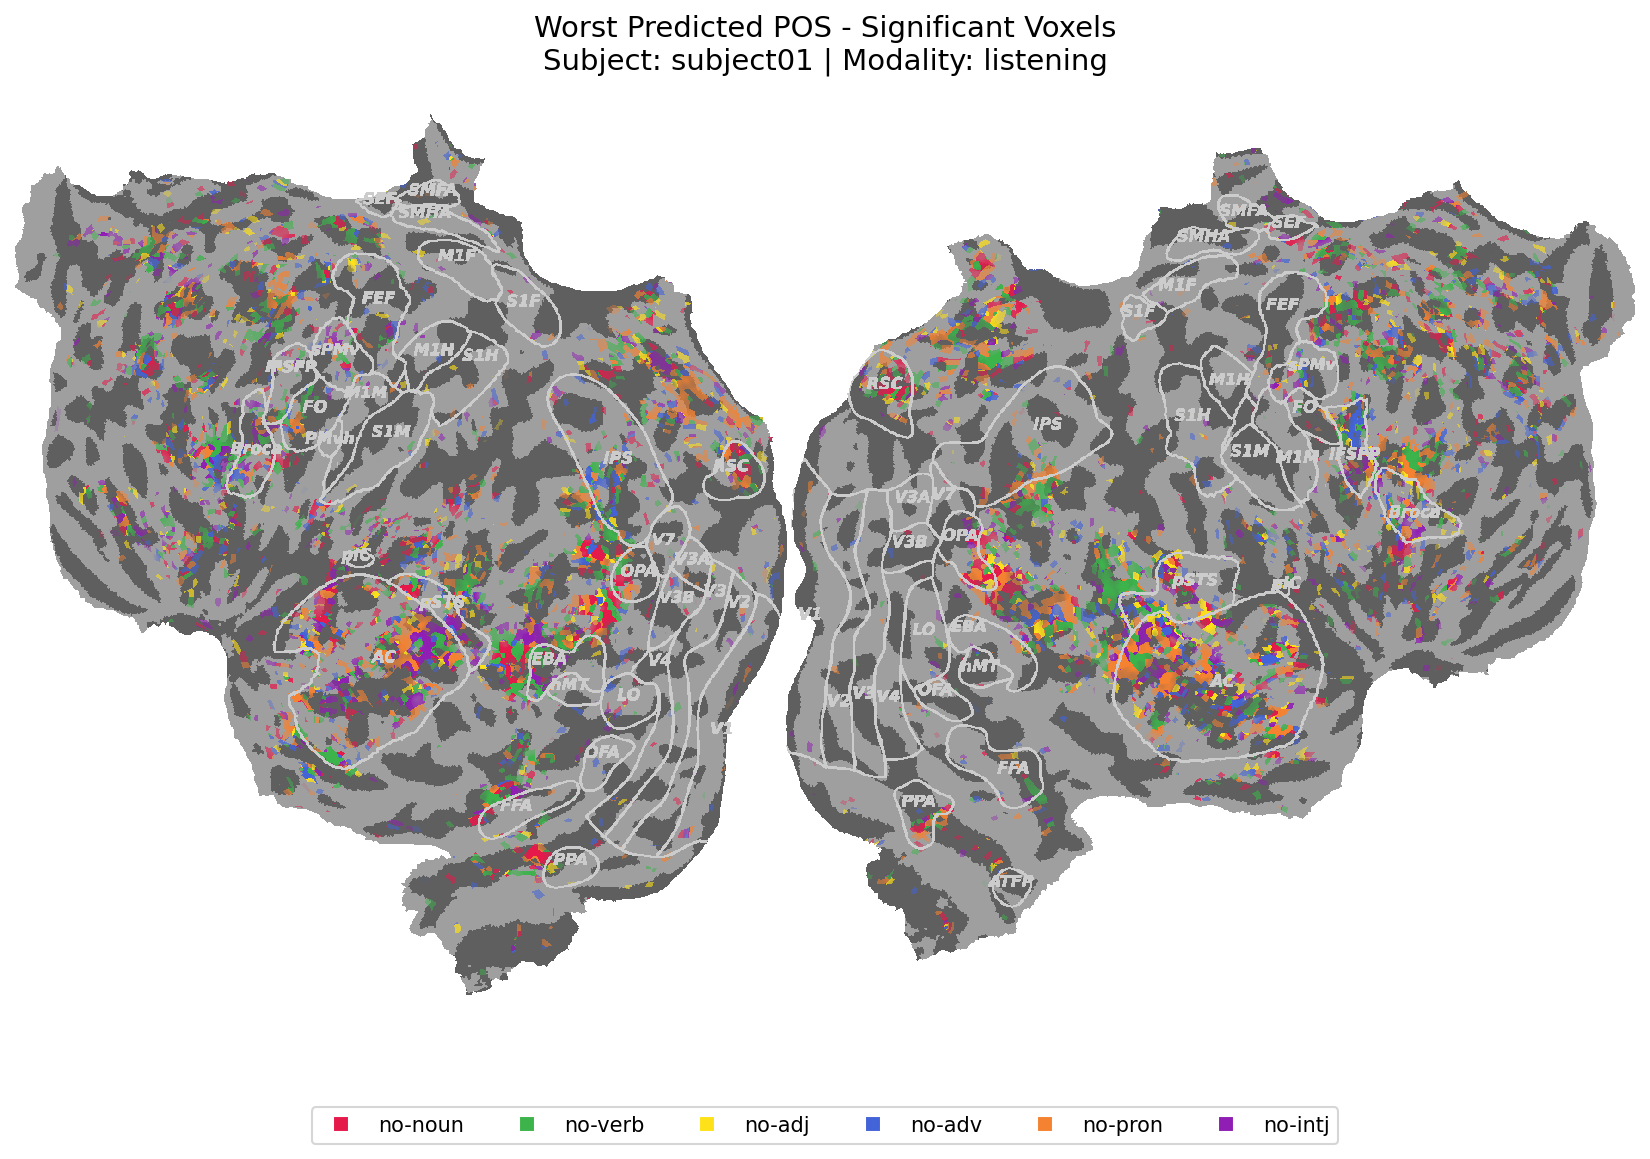

Saved to ../outputs/images/listening/subject01/test/subject01_second_worst_significant


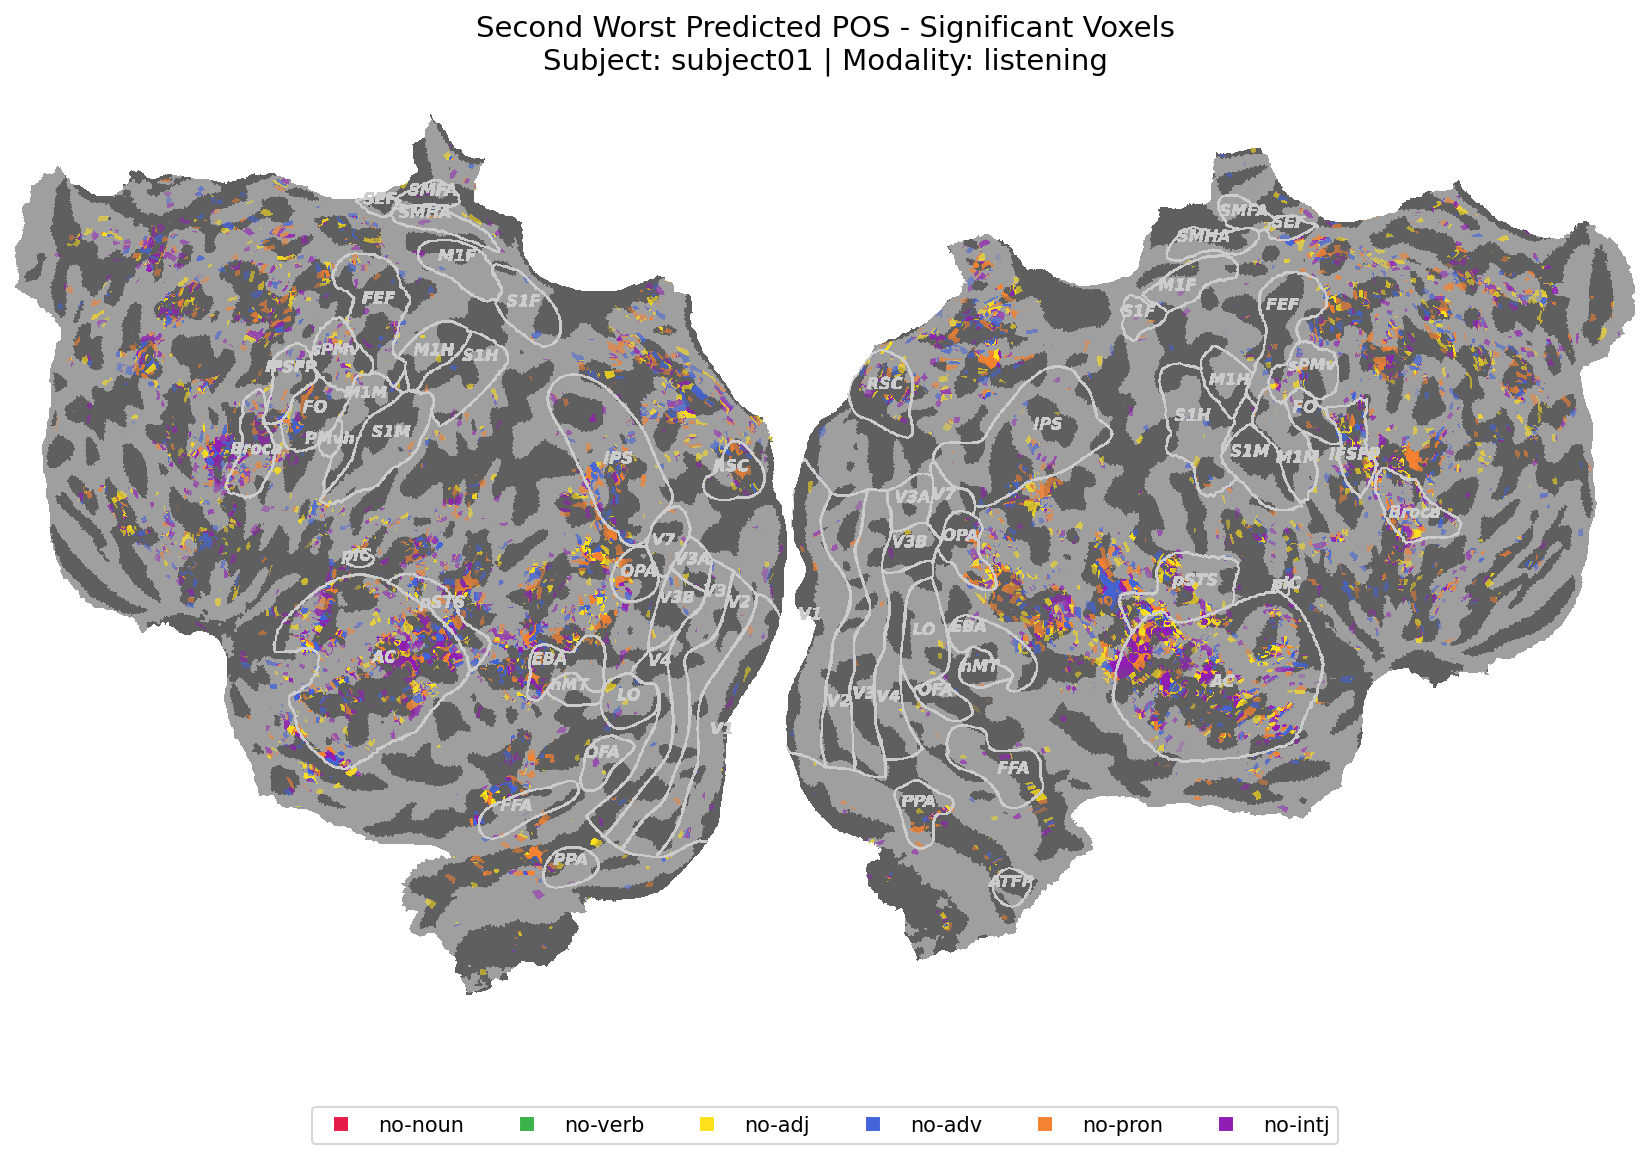

Saved to ../outputs/images/listening/subject06/test/subject06_worst_significant


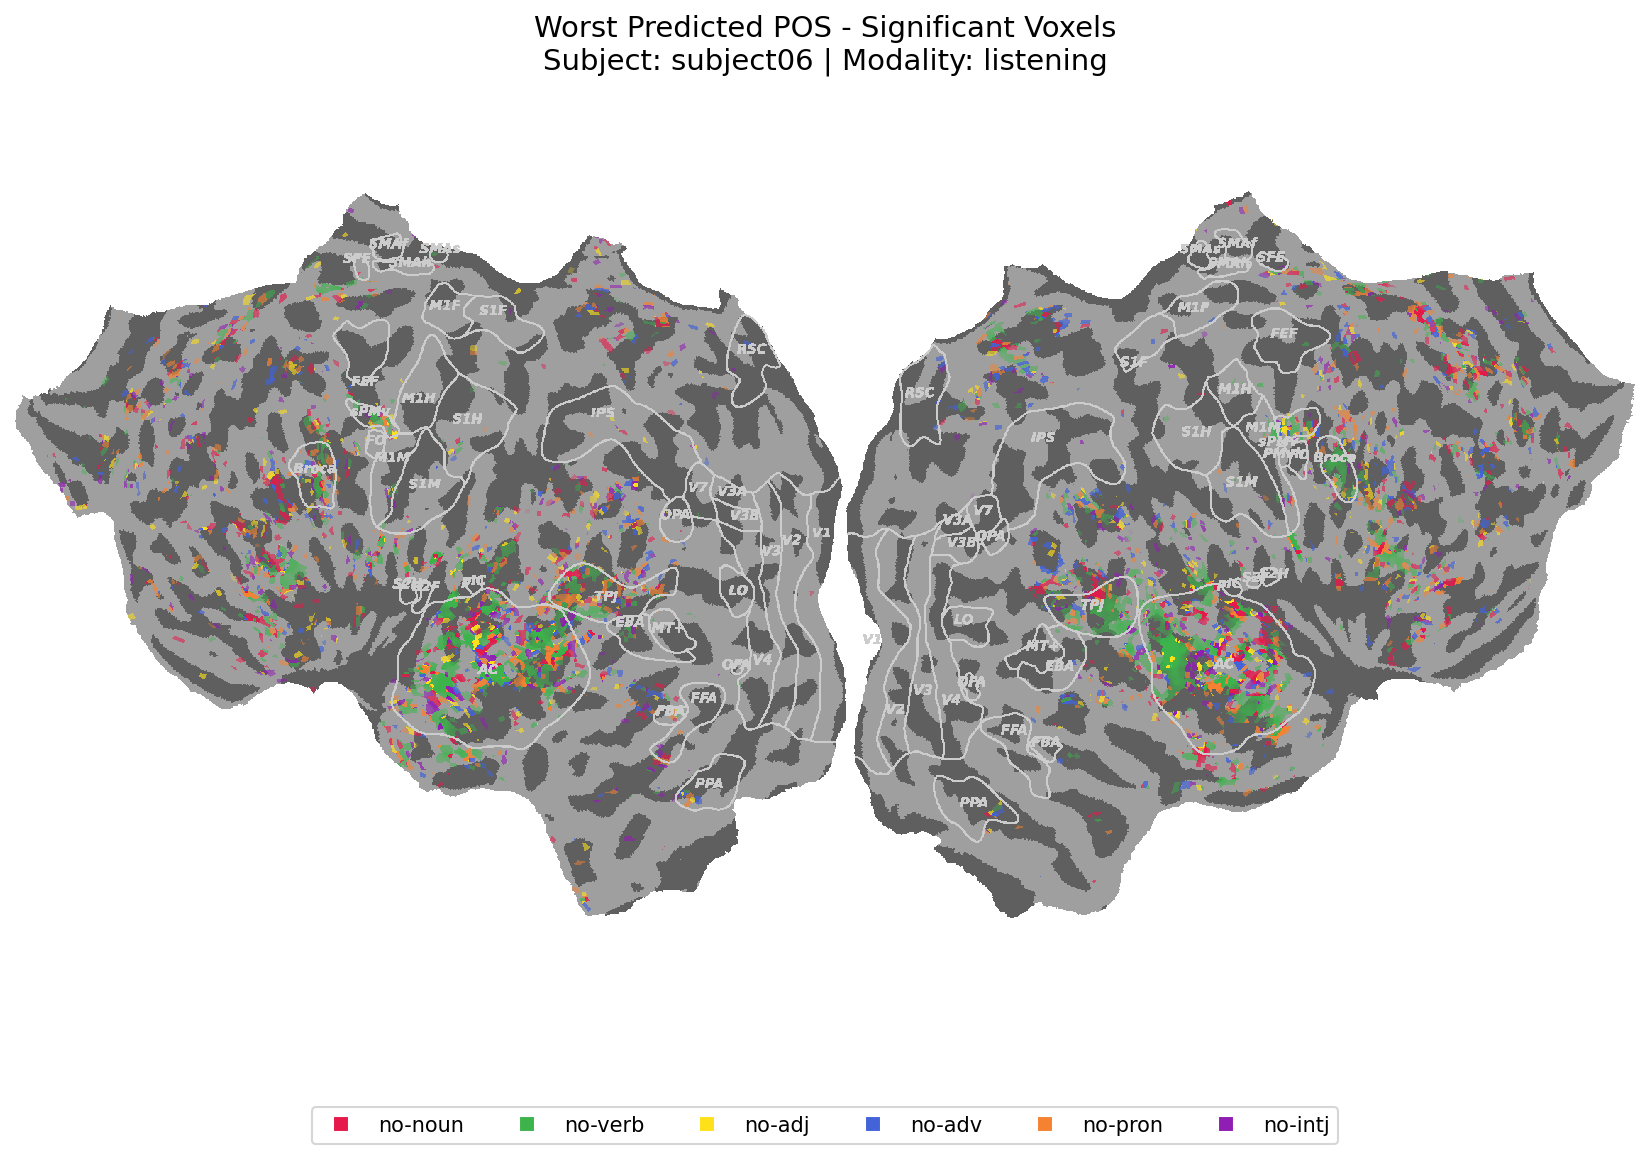

Saved to ../outputs/images/listening/subject06/test/subject06_second_worst_significant


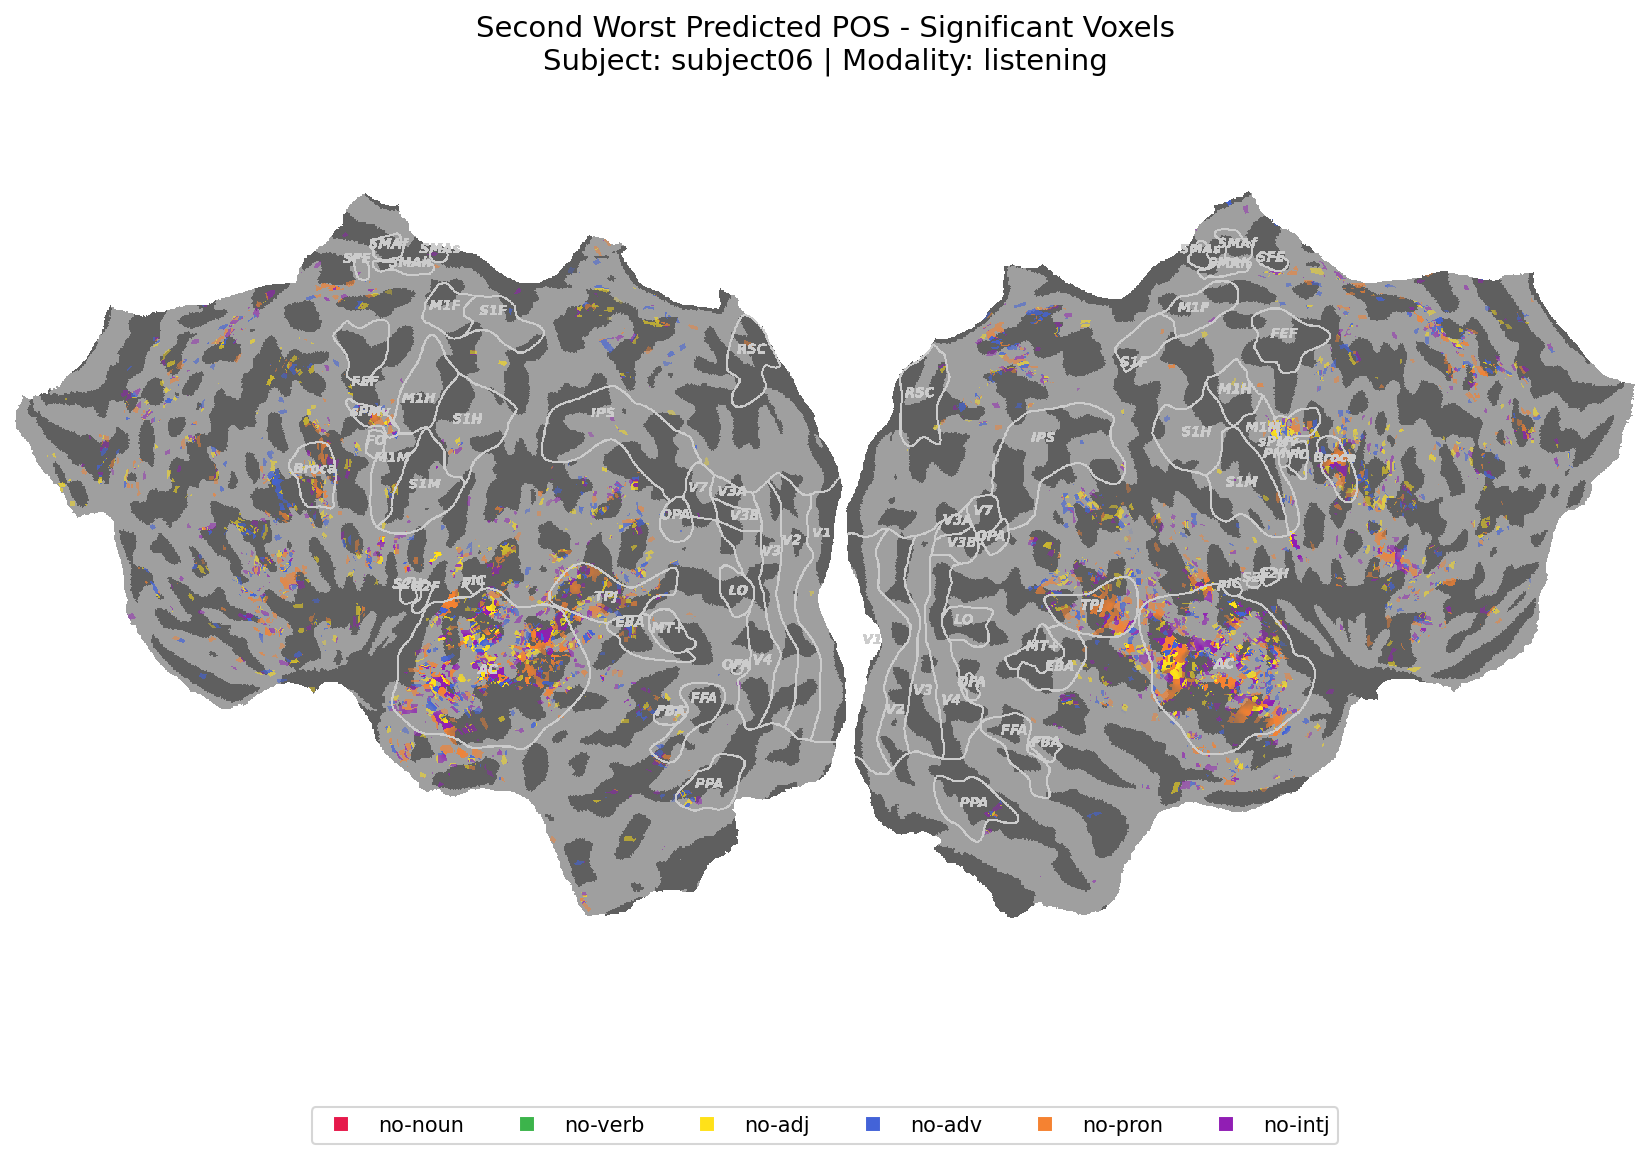

Saved to ../outputs/images/listening/subject07/test/subject07_worst_significant


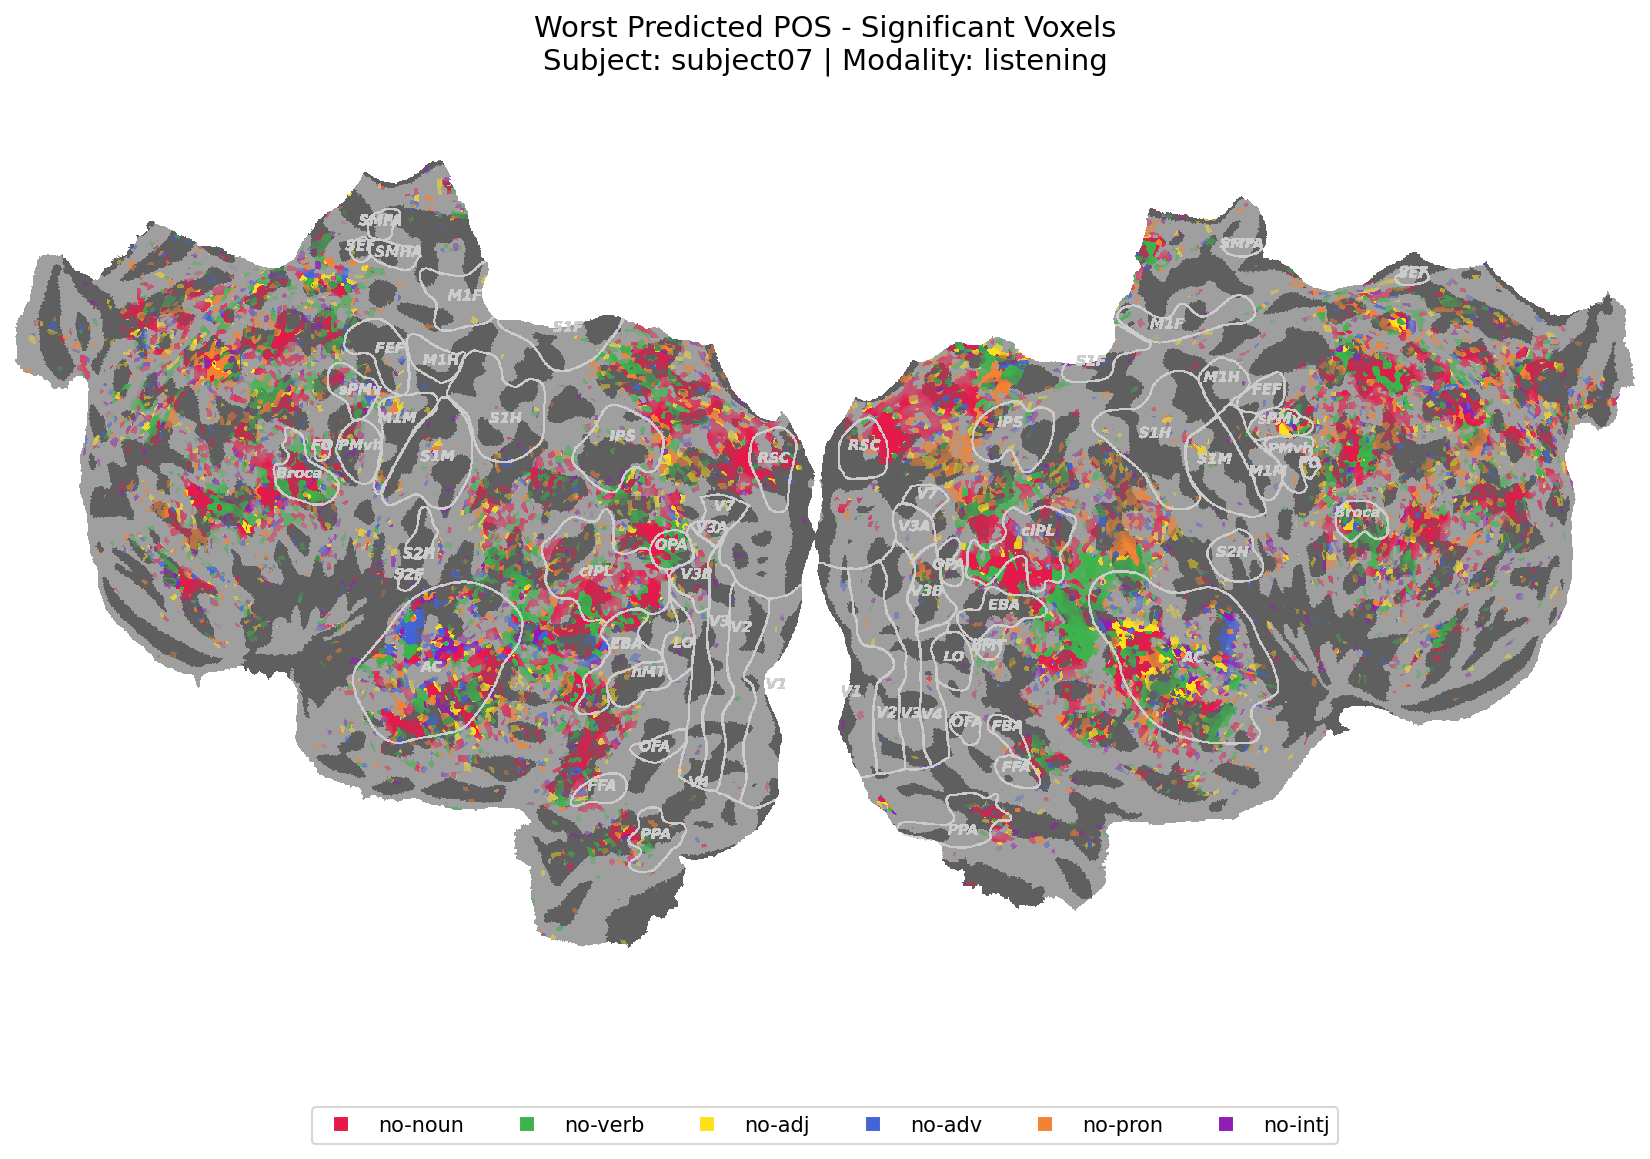

Saved to ../outputs/images/listening/subject07/test/subject07_second_worst_significant


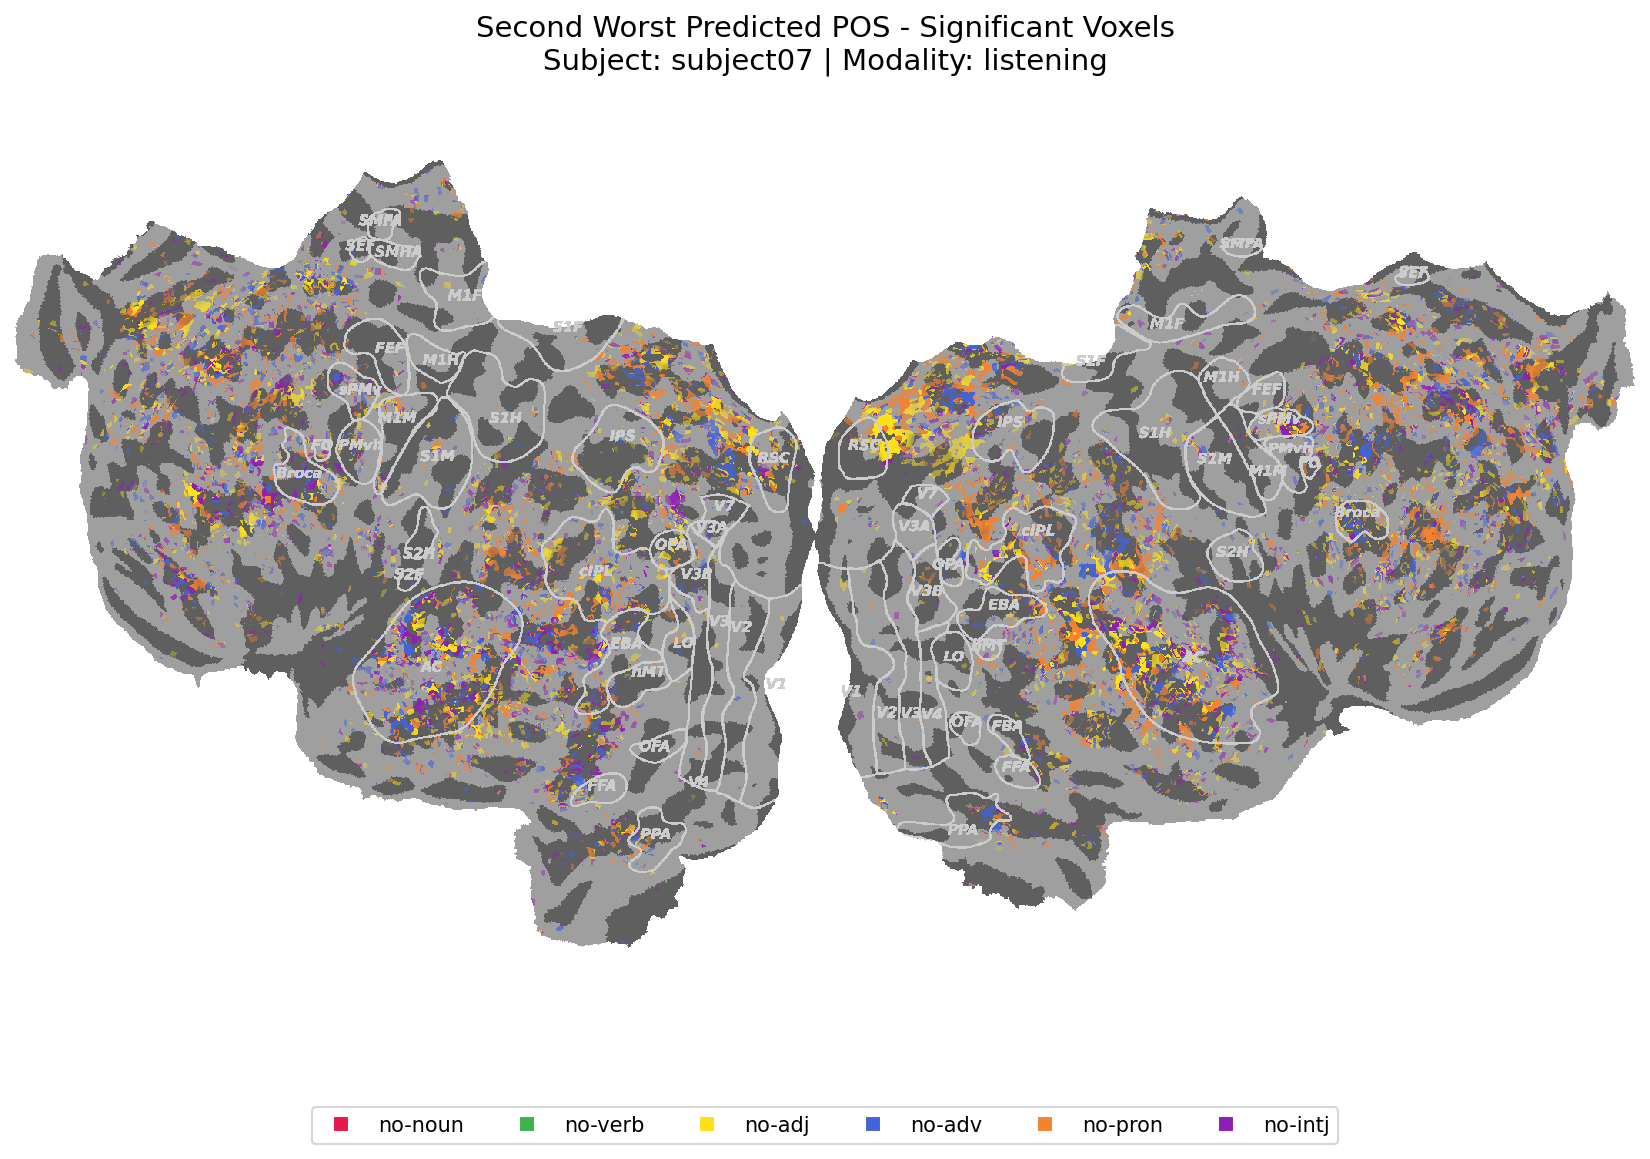

In [4]:
for subject in [config.SUBJECTS[0], config.SUBJECTS[5], config.SUBJECTS[6]]:
    mapper = FlatmapMapper(subject, root_dir/config.MAPPER_PATH)
    fig_config = FigureConfig(
        figsize=(12, 8), 
        save=True, 
        smooth=True, 
        show=True,
        show_regions=True,
        output_dir=root_dir/config.IMAGES_DIR/modality/subject/"test",
    )
    plotter = FlatmapPlotter(mapper, fig_config)
    results = file_io.load_results(
        root_dir / config.OUTPUT_DIR / "results",
        modality,
        subject
    )
    baseline = get_significant_voxels(results, 'baseline')
    data = [get_significant_voxels(results, mode) for mode in modes] 
    data = np.vstack((data, baseline))
    _ = plotter.plot(
        data = data,
        strategy = LoserTakesItAllStrategy(names=names, rank=0),
        title = title.format(
            title = "Worst Predicted POS - Significant Voxels", 
            subject=subject, 
            modality=modality
        ),
        output_filename = f'{subject}_worst_significant'
    )
    _ = plotter.plot(
        data = data,
        strategy = LoserTakesItAllStrategy(names=names, rank=1),
        title = title.format(
            title = "Second Worst Predicted POS - Significant Voxels", 
            subject=subject, 
            modality=modality
        ),
        output_filename = f'{subject}_second_worst_significant'
    )

In [45]:
import spacy
import matplotlib.pyplot as plt
from collections import defaultdict

def analyze_pos(text, pos_tags):
    """Analyze parts of speech in text and return percentages."""
    doc = nlp(text)
    pos_counts = defaultdict(int)
    
    for token in doc:
        if token.pos_ in pos_tags:
            pos_counts[token.pos_] += 1
    
    total = sum(pos_counts.values())
    
    percentages = {tag: (pos_counts[tag] / total * 100) if total > 0 else 0 for tag in pos_tags}
    
    return percentages

## BAR PLOT

In [ ]:
nlp = spacy.load("en_core_web_sm")

# Sample stories (replace with your actual data)
stories = file_io.load_dataseqs(root_dir / config.DATASEQ_PATH, config.STORIES)
stories = {'story ' + str(i): ' '.join(v.data) for i, v in enumerate(stories.values())}

In [ ]:
pos = {}
pos_tags = ['NOUN', 'VERB', 'ADJ', 'ADV', 'PRON', 'INTJ']
for story_name, text in stories.items():
    pos[story_name] = analyze_pos(text, pos_tags)

# Prepare data for plotting
story_names = list(pos.keys())
nouns = [pos[s]["NOUN"] for s in story_names]
verbs = [pos[s]["VERB"] for s in story_names]
adjectives = [pos[s]["ADJ"] for s in story_names]
adverbs = [pos[s]["ADV"] for s in story_names]
pronouns = [pos[s]["PRON"] for s in story_names]
interjections = [pos[s]["INTJ"] for s in story_names]

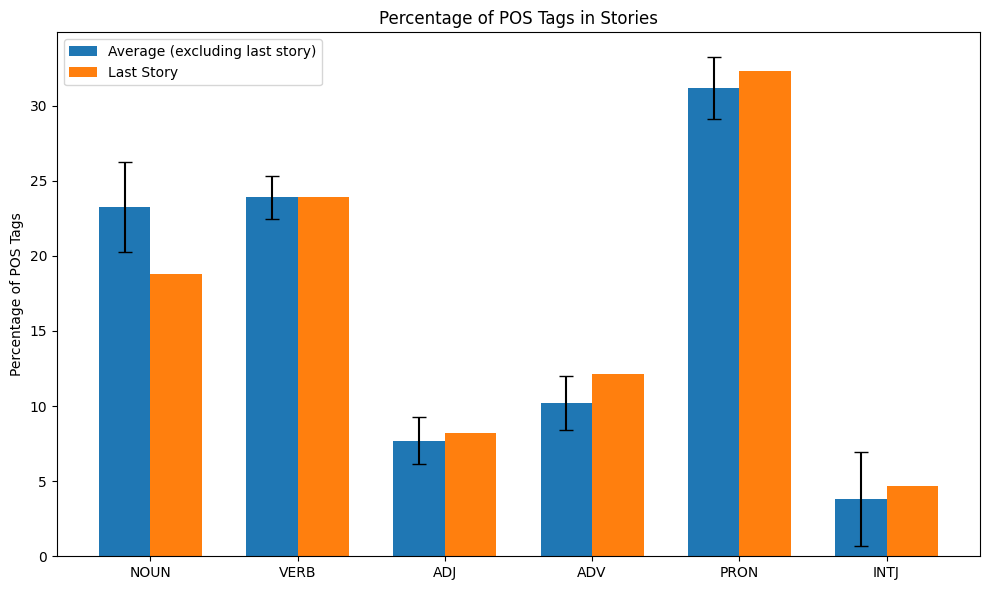

In [54]:
# Create bar chart that shows the percentage (y-axis) of each POS tag (x-axis) with its standard deviation (error bars)
# it should show two bars per POS tag: one for the average percentage across all stories except the last one, and one for the last story
import numpy as np
labels = ['NOUN', 'VERB', 'ADJ', 'ADV', 'PRON', 'INTJ']
x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars
averages = [
    np.mean(nouns[:-1]), 
    np.mean(verbs[:-1]), 
    np.mean(adjectives[:-1]), 
    np.mean(adverbs[:-1]), 
    np.mean(pronouns[:-1]), 
    np.mean(interjections[:-1])
]
std_devs = [
    np.std(nouns[:-1]), 
    np.std(verbs[:-1]),
    np.std(adjectives[:-1]),
    np.std(adverbs[:-1]),
    np.std(pronouns[:-1]),
    np.std(interjections[:-1])
]
last_story = [
    nouns[-1],
    verbs[-1],
    adjectives[-1],
    adverbs[-1],
    pronouns[-1],
    interjections[-1]
]
fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, averages, width, yerr=std_devs, label='Average (excluding last story)', capsize=5)
rects2 = ax.bar(x + width/2, last_story, width, label='Last Story')
ax.set_ylabel('Percentage of POS Tags')
ax.set_title('Percentage of POS Tags in Stories')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
plt.tight_layout()
plt.show()

## DROP PLOT

In [56]:
def compute_margin(corr, baseline):
    stacked = np.stack(corr, axis=0)
    stacked-= baseline
    worst_indices = np.argsort(stacked, axis=0)[0]
    second_worst_indices = np.argsort(stacked, axis=0)[1]

    worst_vals = stacked[worst_indices, np.arange(stacked.shape[1])]
    second_worst_vals = stacked[second_worst_indices, np.arange(stacked.shape[1])]

    margin = second_worst_vals- worst_vals
    return margin

In [75]:
for subject in [config.SUBJECTS[0], config.SUBJECTS[5], config.SUBJECTS[6]]:
    mapper = FlatmapMapper(subject, root_dir/config.MAPPER_PATH)
    fig_config = FigureConfig(
        figsize=(12, 8), 
        save=True, 
        smooth=True, 
        show=False,
        show_regions=True,
        output_dir=root_dir/config.IMAGES_DIR/modality/subject/"test",
    )
    plotter = FlatmapPlotter(mapper, fig_config)
    results = file_io.load_results(
        root_dir / config.OUTPUT_DIR / "results",
        modality,
        subject
    )
    data = [get_significant_voxels(results, mode) for mode in modes] 
    baseline = get_significant_voxels(results, 'baseline')
    margin = compute_margin(data, baseline)
    pct = np.nanpercentile(margin, 95)
    print(pct)
    _ = plotter.plot(
        data = [margin],
        strategy = SingleCorrelationStrategy(vmax = pct),
        title = title.format(
            title = "Worst vs Second Worst - Significant Voxels", 
            subject=subject, 
            modality=modality
        ),
        output_filename = f'{subject}_margins'
    )

0.041975956
Saved to ../outputs/images/listening/subject01/test/subject01_margins
0.037594277
Saved to ../outputs/images/listening/subject06/test/subject06_margins
0.04746774
Saved to ../outputs/images/listening/subject07/test/subject07_margins
